# Assignment 1: Housing Price Prediction

IE500618 — Group 13: Magnus Grande, Ida Soldal

Dataset: `AmesHousing.csv`, referencing `Ames_Housing_Understanding_the_Dataset.pdf`, both provided as part of the assignment.

Targeting: `SalePrice`.

### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv('AmesHousing.csv')

## Step 1 - Explore and understand the data

> Use appropriate descriptive statistics and visualizations to investigate:
> - the available variables and their data types;
> - the distribution of SalePrice;
> - missing values;
> - unusual values or patterns; and
> - relationships that may be useful for predicting house prices.
> 
> Choose analyses and visualizations that help you understand the data and support later decisions. Do not create plots simply for the sake of visualization. Use the dataset guide when terminology is unclear.

In [3]:
# 1 - The available variables and their data types

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")  # ensure row/col count is as expected
print(df.dtypes.value_counts())  # how many columns per data type

Shape: 2930 rows, 82 columns
str        43
int64      28
float64    11
Name: count, dtype: int64


In [4]:
df.head()  # peek at what the actual data looks like

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


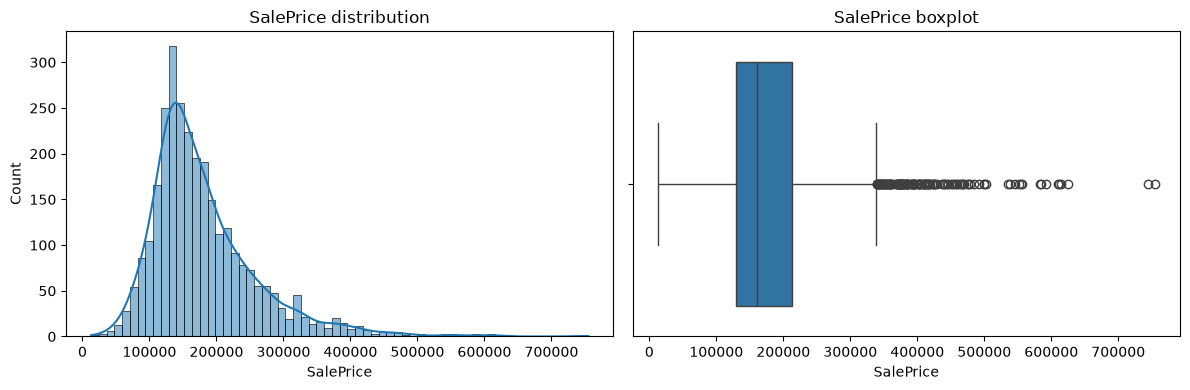

Skewness: 1.74
Above the upper whisker (> 339,500): 137 houses, below the lower whisker (< 3,500): 0
Skewness after taking the log: -0.01


In [5]:
# 2 - Distribution of SalePrice

print(df['SalePrice'].describe())  # summary stats: mean, median, min/max, quartiles

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])  # shape of the distribution
axes[0].set_title('SalePrice distribution')
sns.boxplot(x=df['SalePrice'], ax=axes[1])  # spot outliers
axes[1].set_title('SalePrice boxplot')
plt.tight_layout()
plt.show()

# The numbers behind the shape
sale = df['SalePrice']
print(f"Skewness: {sale.skew():.2f}")  # > 0 means right-skewed (a long tail of high prices)
q1, q3 = sale.quantile([0.25, 0.75])
iqr = q3 - q1  # spread of the middle 50% of houses
upper_whisker, lower_whisker = q3 + 1.5 * iqr, q1 - 1.5 * iqr  # the boxplot's rule for drawing points as outliers
print(f"Above the upper whisker (> {upper_whisker:,.0f}): {(sale > upper_whisker).sum()} houses, below the lower whisker (< {lower_whisker:,.0f}): {(sale < lower_whisker).sum()}")  # which side is the tail on?
print(f"Skewness after taking the log: {np.log(sale).skew():.2f}")  # how symmetric the log-transformed price would be

We see that `SalePrice` is right-skewed. The mean (`$180,796`) is considerably higher than the median (`$160,000`) with a skewness of `1.74`. Half of the houses sell between `$129,500` and `$213,500`, while a few sell far higher (max `$755,000`). The 137 points beyond the boxplot whisker (above `$339,500`) are all genuine expensive houses, not data errors, so we keep them (unlike the huge-area "Partial" sales we later remove in Step 3).

Why this matters:
- RMSE squares the errors, so a miss on a `$600,000` house weighs far more than the same miss on a `$130,000` house. The expensive end will dominate the score (checked on the test errors in Step 6) meaning that the model will be optimized for the expensive houses at the cost of the cheaper ones. **This could potentially be worth noting if we ever decide to split out a separate model for the expensive houses.**
- Linear regression assumes the errors have a roughly constant spread, which a skewed target tends to violate (bigger houses, bigger errors). Taking the log of `SalePrice` makes it symmetric (skewness `-0.01`, printed above) and turns the model's effects into percentage changes instead of dollar amounts. 
  - A 10% increase in `GrLivArea` (living area) is more meaningful than a $100 increase, as the latter is a different percentage for a small house vs. a large house.
  - A 10% increase in `OverallQual` (quality) is more meaningful than a 1-point increase, as the latter is a different percentage for a low-quality house vs. a high-quality house.
- We train on raw `SalePrice` for now so that RMSE stays in dollars, as the assignment defines it. A log-transformed target is a candidate improvement for Q7.

In [6]:
# 3 - Missing values

missing = df.isna().sum().sort_values(ascending=False)  # count missing per column
missing_pct = (missing / len(df) * 100).round(1)  # convert to percentage
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table[missing_table['missing_count'] > 0]  # only show columns with any missing values

,missing_count,missing_pct
Pool QC,2917,99.6
Misc Feature,2824,96.4
Alley,2732,93.2
Fence,2358,80.5
Mas Vnr Type,1775,60.6
Fireplace Qu,1422,48.5
Lot Frontage,490,16.7
Garage Qual,159,5.4
Garage Yr Blt,159,5.4
Garage Cond,159,5.4


## Missing values 

The reference document says a missing value has one of two meanings: 

- the feature is **not present** (e.g. no fireplace, so `Fireplace Qu` is missing) 

or 

- the value was **not recorded** (e.g. `Lot Frontage`). Pandas shows both as `NaN`, so we read 
the guide column by column:

| Guide says | Columns |
|---|---|
| Missing = feature absent | `Alley`, `Fireplace Qu`, `Pool QC`, `Fence`, `Misc Feature` |
| Usually feature absent, but *not recorded* if a related column shows the feature exists | Basement: `Bsmt Qual`, `Bsmt Cond`, `Bsmt Exposure`, `BsmtFin Type 1`, `BsmtFin Type 2` |
| | Garage: `Garage Type`, `Garage Finish`, `Garage Qual`, `Garage Cond`, `Garage Yr Blt` |
| | Veneer: `Mas Vnr Type` |
| Value not recorded, unknown number | `Lot Frontage`, `Mas Vnr Area`, `BsmtFin SF 1`, `BsmtFin SF 2`, `Bsmt Unf SF`, `Total Bsmt SF`, `Bsmt Full Bath`, `Bsmt Half Bath`, `Garage Cars`, `Garage Area` |
| Value not recorded, unknown category | `Electrical` |

For the "usually absent" group, we check whether the related column agrees:

In [7]:
# Do the related columns agree with the guide?
# NaN + related column == 0 -> the feature is absent. NaN + related column > 0 -> the feature exists, the value just wasn't recorded.
# 
# Example: `Fireplace Qu` is NaN, but `Fireplaces` is 1. The guide says "missing = absent", 
# but the related column shows that the house does have a fireplace, so the NaN is an unrecorded value.

related = {  # column with NaN: related column that says whether the feature exists
    'Fireplace Qu': 'Fireplaces', 'Pool QC': 'Pool Area', 'Misc Feature': 'Misc Val',  # guide: missing = absent (sanity check only)
    'Bsmt Qual': 'Total Bsmt SF', 'Bsmt Cond': 'Total Bsmt SF', 'Bsmt Exposure': 'Total Bsmt SF',
    'BsmtFin Type 1': 'Total Bsmt SF', 'BsmtFin Type 2': 'Total Bsmt SF',
    'Garage Type': 'Garage Area', 'Garage Finish': 'Garage Area', 'Garage Qual': 'Garage Area',
    'Garage Cond': 'Garage Area', 'Garage Yr Blt': 'Garage Area',
    'Mas Vnr Type': 'Mas Vnr Area',
}  # Alley and Fence have no related column, the guide says missing = no alley/fence

rows = []
for col, rel in related.items():
    na = df[col].isna()  # rows where this column is missing
    rows.append({
        'column': col, 'related column': rel, 'missing': na.sum(),
        'related == 0 (absent)': (na & (df[rel] == 0)).sum(),  # confirms "feature absent"
        'related > 0 (exists, not recorded)': (na & (df[rel] > 0)).sum(),  # feature exists, so the NaN is an unrecorded value
        'related also missing': (na & df[rel].isna()).sum(),  # can't tell from the related column
    })
pd.DataFrame(rows).set_index('column')

,related column,missing,related == 0 (absent),"related > 0 (exists, not recorded)",related also missing
column,,,,,
Fireplace Qu,Fireplaces,1422,1422,0,0
Pool QC,Pool Area,2917,2917,0,0
Misc Feature,Misc Val,2824,2824,0,0
Bsmt Qual,Total Bsmt SF,80,79,0,1
Bsmt Cond,Total Bsmt SF,80,79,0,1
Bsmt Exposure,Total Bsmt SF,83,79,3,1
BsmtFin Type 1,Total Bsmt SF,80,79,0,1
BsmtFin Type 2,Total Bsmt SF,81,79,1,1
Garage Type,Garage Area,157,157,0,0


We see that the vast majority of missing values line up with a related value of 0 (no basement, garage, veneer, fireplace or pool). The exceptions are the rows where the feature clearly exists but a value is missing, e.g. three houses with a basement but no `Bsmt Exposure`, or the house with `Order` 2237 that has a detached garage but no `Garage Area`. Those values were not recorded, so filling them with "None" or 0 would be wrong.

### Unusual values
Price should generally rise with size (source: our own experiences with finding student accommodation), so a house that is very large but sold cheaply can be a good candidate for further investigation, given we're specifically being asked to identify unusual values and all that. `Gr Liv Area` (above-ground living area in square feet, according to the guide) is the most direct size measure, so we can plot price against it. We colour the points by `Sale Condition`, which the guide describes as the special circumstances of the sale (foreclosure, family sale, unfinished home and so on), because a price that does not come from an ordinary sale could explain an odd point.

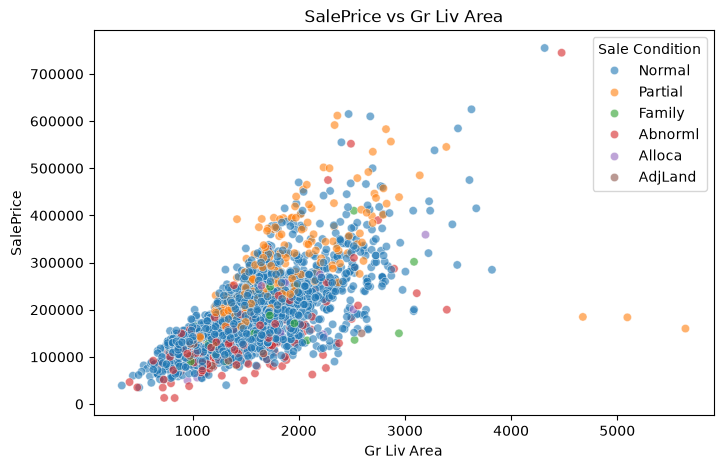

Median price per sq ft, all houses: 120
Size-price correlation, all houses: 0.707; without the 3 flagged: 0.727


,Gr Liv Area,SalePrice,Sale Condition,Overall Qual,Price per sq ft
1498,5642,160000,Partial,10,28.0
2180,5095,183850,Partial,10,36.0
2181,4676,184750,Partial,10,40.0
1760,4476,745000,Abnorml,10,166.0
1767,4316,755000,Normal,10,175.0
1497,3820,284700,Normal,5,75.0
2737,3672,415000,Normal,6,113.0
2445,3627,625000,Normal,10,172.0


In [8]:
# 4 - Unusual values or patterns
# Price normally rises with size, so a very large house with a low price stands out.
# Colour by Sale Condition to see if the odd points have something in common.

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice', hue='Sale Condition', alpha=0.6, ax=ax)  # size vs price, coloured by sale circumstances
ax.set_title('SalePrice vs Gr Liv Area')
plt.show()

biggest = df.nlargest(8, 'Gr Liv Area')[['Gr Liv Area', 'SalePrice', 'Sale Condition', 'Overall Qual']].copy()  # the 8 largest houses, to see where the odd ones end
biggest['Price per sq ft'] = (biggest['SalePrice'] / biggest['Gr Liv Area']).round()  # what each house sold for per square foot
print(f"Median price per sq ft, all houses: {(df['SalePrice'] / df['Gr Liv Area']).median():.0f}")  # reference point for the table below

flagged = (df['Gr Liv Area'] > 4000) & (df['Sale Condition'] == 'Partial')  # the group we are considering removing
print(f"Size-price correlation, all houses: {df['Gr Liv Area'].corr(df['SalePrice']):.3f}; without the {flagged.sum()} flagged: {df.loc[~flagged, 'Gr Liv Area'].corr(df.loc[~flagged, 'SalePrice']):.3f}")  # how much do they matter?

biggest

Five houses are above 4,000 sq ft, with a clear gap down to the next largest (3,820) (This does not include the weird spot on my monitor I thought was a house for way too long -Magnus). They fall into two groups:

- **Three houses (5,642, 5,095 and 4,676 sq ft)** sold for `$160,000` to `$185,000`, roughly `$28` to `$40` per sq ft against a median of `$120`, even with `Overall Qual` 10 ("very excellent"). All three are `Partial` sales, which the guide describes as homes not completed when last assessed, so the price probably does not reflect the finished house. Removing them raises the size-price correlation from 0.707 to 0.727 (printed above), a small but clear effect from three of 2,930 houses.
- **Two houses (4,476 and 4,316 sq ft)** sold for `$745,000` and `$755,000` (`$166` and `$175` per sq ft). They are expensive, but in line with their size and quality 10, so they appear genuine and we keep them.

Decision: remove the three `Partial` houses above 4,000 sq ft, from the training data only (Step 3).

### Relationships with SalePrice
To decide which features could help predict price, we check how strongly each one moves together with `SalePrice`. For numeric columns we use the correlation coefficient: close to 1 means price rises in step with the feature, close to 0 means no straight-line relationship.

In [9]:
# 5 - Relationships that may be useful for predicting house prices
# Numeric columns: correlation with SalePrice. Row identifiers and MS SubClass (a code, not a quantity) are left out.

numeric = df.select_dtypes(include=np.number).drop(columns=['Order', 'PID', 'MS SubClass'])  # only columns where a correlation is meaningful
corr_with_price = numeric.corr()['SalePrice'].sort_values(ascending=False)  # correlation of each numeric col with price
print(corr_with_price.head(11).round(3))  # top 10 most correlated features
                                          # if we could just predict SalePrice from SalePrice itself, we'd be done by now

top_features = corr_with_price.index[1:11]  # the 10 strongest (position 0 is SalePrice itself)
pairs = df[top_features].corr().where(np.triu(np.ones((10, 10), dtype=bool), k=1)).stack()  # correlation between every pair of top features, each pair once
print("\nPairs of top features that are correlated above 0.8 with each other:")
print(pairs[pairs > 0.8].round(2))

SalePrice         1.000
Overall Qual      0.799
Gr Liv Area       0.707
Garage Cars       0.648
Garage Area       0.640
Total Bsmt SF     0.632
1st Flr SF        0.622
Year Built        0.558
Full Bath         0.546
Year Remod/Add    0.533
Garage Yr Blt     0.527
Name: SalePrice, dtype: float64

Pairs of top features that are correlated above 0.8 with each other:
Garage Cars    Garage Area      0.89
Total Bsmt SF  1st Flr SF       0.80
Year Built     Garage Yr Blt    0.83
dtype: float64


Quality (`Overall Qual`, 0.80) and living area (`Gr Liv Area`, 0.71) are the strongest, followed by garage size, basement and first-floor area, and age (`Year Built`, `Year Remod/Add`).

Several of these carry overlapping information: `Garage Cars` and `Garage Area` (0.89) both describe garage size, `Year Built` and `Garage Yr Blt` (0.83) both describe age, and `Total Bsmt SF` and `1st Flr SF` (0.80) both follow the footprint of the house. Two features that move together add little beyond one of them, so `Garage Yr Blt` is dropped in Step 3, and this is why Step 4 instead builds combined features such as `Total SF`.

A correlation only measures a straight-line relationship, so we also look at the shape of the strongest ones.

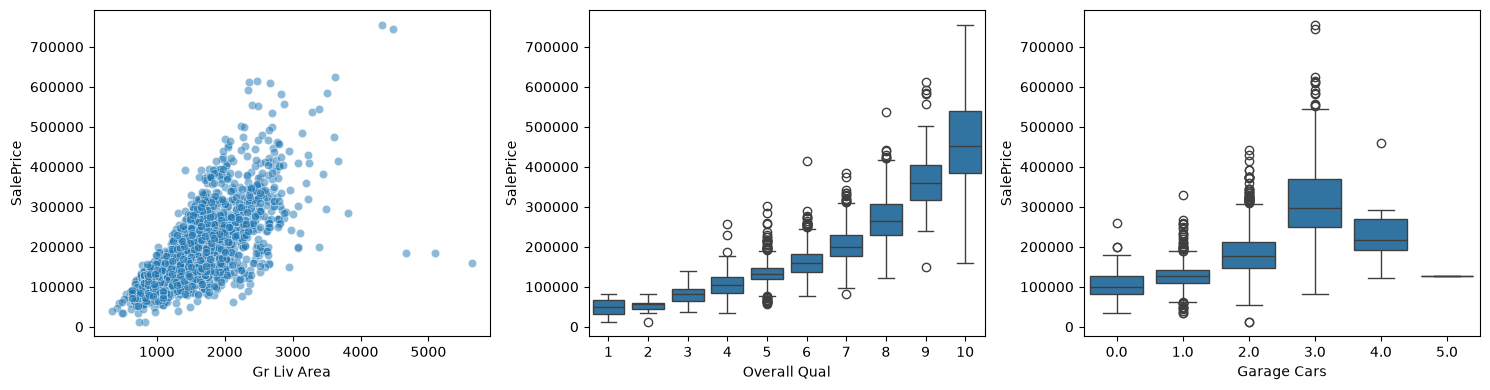

             count    median
Garage Cars                 
0.0            157  100000.0
1.0            778  127000.0
2.0           1603  177000.0
3.0            374  296500.0
4.0             16  216500.0
5.0              1  126500.0
Overall Qual
5      28383
10    154487
Name: Price IQR, dtype: int64


In [10]:
# 5 (cont.) - The shape of the strongest relationships (a correlation only measures straight-line relationships)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice', alpha=0.5, ax=axes[0])  # size is continuous, so a scatter plot
sns.boxplot(data=df, x='Overall Qual', y='SalePrice', ax=axes[1])  # quality is a 1-10 rating, so one box per level
sns.boxplot(data=df, x='Garage Cars', y='SalePrice', ax=axes[2])  # garage capacity is a small count, so one box per value
plt.tight_layout()
plt.show()

print(df.groupby('Garage Cars')['SalePrice'].agg(['count', 'median']))  # how many houses are behind each garage box
print(df.groupby('Overall Qual')['SalePrice'].apply(lambda s: s.quantile(0.75) - s.quantile(0.25)).round().astype(int).rename('Price IQR').loc[[5, 10]])  # spread of price at quality 5 vs 10

- `Gr Liv Area`: price rises roughly in a straight line with size. The spread also widens for larger houses, and the three unfinished "Partial" sales from earlier sit at the bottom right.
- `Overall Qual`: the median price rises at every quality level, and so does the spread. The interquartile range (the height of the box) grows from `$28,383` at quality 5 to `$154,487` at quality 10.
- `Garage Cars`: price rises up to 3 cars, but the 16 houses with a 4-car garage have a lower median (`$216,500`) than the 374 with 3 cars (`$296,500`). So a straight line does not describe this relationship well, which is worth remembering when comparing linear regression with the tree-based models.

Figuring out correlation for categorical columns felt a bit beyond us, but we asked AI for help and it suggested a method that now makes sense to us, and that we felt was worth including:

Correlation only covers numeric columns, and 44 of our features are categories (the text columns plus `MS SubClass`). For those we ask how much of the variation in price is explained by knowing the category: replace every price by the average price of its category, and measure how much of the total variation that captures (1 means the category fully determines the price, 0 means it tells us nothing). This is comparable to the squared correlation of the numeric columns, which is 0.64 for `Overall Qual` and 0.50 for `Gr Liv Area`. A column with many categories gets a somewhat inflated score, so treat the numbers as an upper bound.

44 categorical columns. Strongest and weakest:
Neighborhood     0.573
Bsmt Qual        0.513
Exter Qual       0.505
Kitchen Qual     0.482
Garage Finish    0.308
Fireplace Qu     0.307
Foundation       0.280
Garage Type      0.249
Misc Feature     0.005
Land Slope       0.005
Street           0.004
Utilities        0.001
dtype: float64

MS SubClass: explains 0.248 as a category, but its plain correlation with price is -0.085


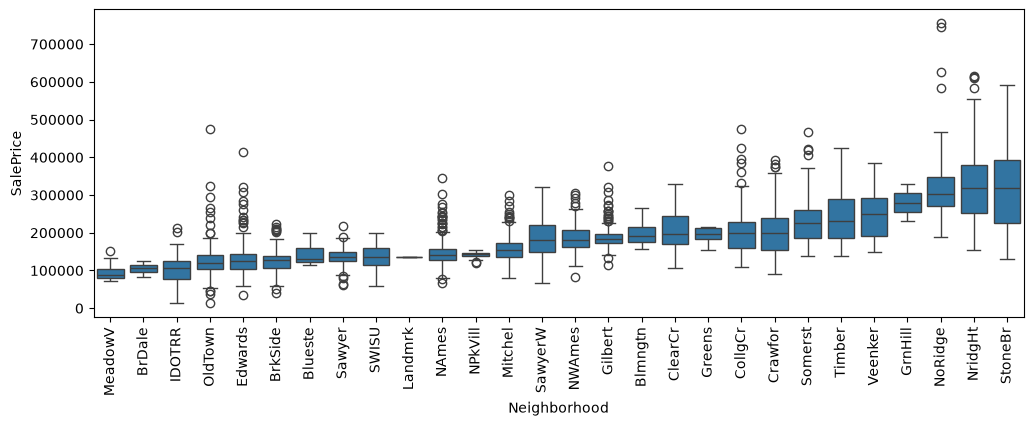

In [11]:
# 5 (cont.) - Categorical columns: how much of the variation in SalePrice does knowing the category explain?

categorical = list(df.select_dtypes(exclude=np.number).columns) + ['MS SubClass']  # text columns + MS SubClass (a category according to the guide)
total_variation = ((df['SalePrice'] - df['SalePrice'].mean()) ** 2).sum()  # total variation in price around the overall mean

explained = {}
for col in categorical:
    category_mean = df.groupby(col, dropna=False)['SalePrice'].transform('mean')  # each price replaced by its category's average (NaN is its own group, it means "no such feature")
    explained[col] = 1 - ((df['SalePrice'] - category_mean) ** 2).sum() / total_variation  # share of the variation that the categories capture
explained = pd.Series(explained).sort_values(ascending=False)

print(f"{len(categorical)} categorical columns. Strongest and weakest:")
print(pd.concat([explained.head(8), explained.tail(4)]).round(3))
print(f"\nMS SubClass: explains {explained['MS SubClass']:.3f} as a category, but its plain correlation with price is {df['MS SubClass'].corr(df['SalePrice']):.3f}")  # why it must not be treated as a number

fig, ax = plt.subplots(figsize=(12, 4))
neighborhood_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index  # cheapest to most expensive neighbourhood
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=neighborhood_order, ax=ax)  # the strongest categorical feature
ax.tick_params(axis='x', rotation=90)
plt.show()

`Neighborhood` explains 57% of the variation in price, more than living area alone, and the quality ratings for the basement, the exterior and the kitchen (`Bsmt Qual`, `Exter Qual`, `Kitchen Qual`) each explain about half. `MS SubClass` shows why the guide's type matters: as a number its correlation with price is -0.085, but as a category it explains 25% of the variation. At the other end, columns such as `Utilities`, `Street` and `Land Slope` explain almost nothing.

**What this means for the next steps:** the useful features are overall quality, size (living area, basement, first floor), garage, age and location (`Neighborhood`), plus the quality ratings. They overlap with each other, so we combine some of them (Step 4: `Total SF` from the size columns, `House Age` from `Year Built`), and the categorical columns must be encoded before the models can use them (Step 3).

## Step 2 - Create training and test data

Split the dataset into training and test sets. Use the training data to develop your solution and keep the test data separate for final evaluation on unseen data.

In [12]:
# Split the dataset into training and test sets
X = df.drop(columns=['SalePrice'])  # features = everything except the target
y = df['SalePrice']  # target = the price we want to predict

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)  # 80/20 split, reproducible via random_state
                                                                                           # haha funny number
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")  # confirm split sizes

# Test set is set aside now and left untouched until final evaluation, so preprocessing/feature/model choices can't leak information from it

Train: 2344 rows, Test: 586 rows


## Step 3 - Prepare the data

> Using the training data, decide how to prepare the data for the models. This may include:
> - handling missing values based on what they represent in the Understanding the Dataset guide;
> - encoding categorical variables;
> - scaling or transforming numerical variables where appropriate; and
> - removing variables when there is a clear reason to do so.
> 
> **Important:** Preprocessing should be learned from the training data and then applied in the same way to the test data. Do not learn preprocessing from the complete dataset, and do not fit preprocessing separately on the test data.

In [13]:
# Remove the outlier unusual rows flagged in Step 1, from training data only (test set is left untouched)
outlier_mask = (X_train['Gr Liv Area'] > 4000) & (X_train['Sale Condition'] == 'Partial')  # the Step 1 outliers: over 4,000 sq ft, low price, 
                                                                                           # home not completed when assessed ("Partial"); 
                                                                                           # the two other huge houses are priced in line with their size and stay
n_outliers = outlier_mask.sum()  # how many rows match

X_train = X_train[~outlier_mask]  # drop them from features
y_train = y_train[~outlier_mask]  # drop matching rows from target, keeping index alignment

print(f"Removed {n_outliers} outlier rows from training data. New train size: {X_train.shape[0]}")  # confirm removal

# Only removed from training data

Removed 3 outlier rows from training data. New train size: 2341


In [14]:
# 4 - Removing variables when there is a clear reason to do so

id_cols = ['Order', 'PID']  # row identifiers, carry no predictive information
X_train = X_train.drop(columns=id_cols)  # drop from train
X_test = X_test.drop(columns=id_cols)  # drop from test

X_train = X_train.drop(columns=['Garage Yr Blt'])  # redundant with Year Built, and awkward to fill for "no garage" rows
X_test = X_test.drop(columns=['Garage Yr Blt'])  # same drop applied to test

print(f"Columns remaining: {X_train.shape[1]}")  # confirm drop

# Done first (before filling missing values) so Garage Yr Blt's many "no garage" gaps never need to be imputed at all

Columns remaining: 78


### Handling missing values

To action on the missing values we identified in step 1, each group from that table gets its own rule.

- **Feature absent** (`Alley`, `Fireplace Qu`, `Pool QC`, `Fence`, `Misc Feature`): `'None'` category.
- **Usually absent, unless the related column shows the feature exists** (basement, garage, `Mas Vnr Type`): `'None'` when the related column is 0, otherwise `'Unknown'` (exists, but not recorded). This runs *before* the numeric fill, while the related columns still hold their original values.
- **Not recorded, number** (`Lot Frontage`, `Mas Vnr Area`, basement and garage areas/counts): training-set median, which is less sensitive to the skewed area columns than the mean.
- **Not recorded, category** (`Electrical`): `'Unknown'` category.

`Garage Yr Blt` was dropped in the previous step, so it needs no fill.

In [15]:
# 1 - Handling missing values based on what they represent in the Understanding the Dataset guide
# (evidence for each rule is in the Step 1 "What do these missing values mean?" section)

# (a) Guide: missing = feature absent
absent_cols = ['Alley', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature']

# (b) Guide: usually absent, but not recorded if a related column shows the feature exists
conditional_cols = {  # column with NaN: related column that says whether the feature exists
    'Bsmt Qual': 'Total Bsmt SF', 'Bsmt Cond': 'Total Bsmt SF', 'Bsmt Exposure': 'Total Bsmt SF',
    'BsmtFin Type 1': 'Total Bsmt SF', 'BsmtFin Type 2': 'Total Bsmt SF',
    'Garage Type': 'Garage Area', 'Garage Finish': 'Garage Area', 'Garage Qual': 'Garage Area', 'Garage Cond': 'Garage Area',
    'Mas Vnr Type': 'Mas Vnr Area',
}

# (c) Guide: value not recorded, treat as an unknown number
median_cols = ['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
               'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area']
medians = X_train[median_cols].median()  # learned from training data only

# (d) Guide: Electrical not recorded, treat as an unknown category

for X in (X_train, X_test):  # the same rules are applied to train and test
    X[absent_cols] = X[absent_cols].fillna('None')  # (a)

    for col, rel in conditional_cols.items():  # (b) must run before (c), while the related columns are still unfilled
        missing = X[col].isna()
        absent = X[rel] == 0  # related column confirms the feature doesn't exist
        X.loc[missing & absent, col] = 'None'  # feature absent
        X.loc[missing & ~absent, col] = 'Unknown'  # feature exists (or can't be ruled out), value not recorded

    X[median_cols] = X[median_cols].fillna(medians)  # (c) same training medians for train and test
    X['Electrical'] = X['Electrical'].fillna('Unknown')  # (d)

print("Remaining missing values -- train:", X_train.isna().sum().sum(), "test:", X_test.isna().sum().sum())  # confirm 0 in both

unknown = pd.DataFrame({'train': (X_train[[*conditional_cols, 'Electrical']] == 'Unknown').sum(),
                        'test': (X_test[[*conditional_cols, 'Electrical']] == 'Unknown').sum()})
print("\n'Unknown' (not recorded) per column:")
print(unknown[unknown.sum(axis=1) > 0])  # only a handful of rows, most NaNs were real absences

# Absent -> 'None', not recorded -> 'Unknown' (categories) or the training median (numbers)

Remaining missing values -- train: 0 test: 0

'Unknown' (not recorded) per column:
                train  test
Bsmt Qual           1     0
Bsmt Cond           1     0
Bsmt Exposure       4     0
BsmtFin Type 1      1     0
BsmtFin Type 2      2     0
Garage Finish       1     1
Garage Qual         1     1
Garage Cond         1     1
Mas Vnr Type       21     9
Electrical          1     0


In [16]:
# 2 - Encoding categorical variables

categorical_cols = list(X_train.select_dtypes(exclude=np.number).columns) + ['MS SubClass']  # text columns + MS SubClass (stored as int, but documented as a Category: a house-type code)
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]  # everything else, kept aside for scaling next

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # ignore categories only seen in test instead of crashing
encoder.fit(X_train[categorical_cols])  # learn categories from training data only

train_encoded = pd.DataFrame(encoder.transform(X_train[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index)  # apply to train
test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols), index=X_test.index)  # apply the SAME fitted encoder to test

X_train = pd.concat([X_train[numeric_cols], train_encoded], axis=1)  # swap raw categories for encoded columns
X_test = pd.concat([X_test[numeric_cols], test_encoded], axis=1)  # same swap for test

print(f"Columns after encoding: {X_train.shape[1]}")  # confirm new column count

# Encoder is fit on training categories only; a category seen only in test is safely ignored (all-zero row) instead of breaking the pipeline

Columns after encoding: 336


In [17]:
# 3 - Scaling or transforming numerical variables where appropriate

scaler = StandardScaler()  # standardize to mean 0, std 1
scaler.fit(X_train[numeric_cols])  # learn mean/std from training data only

X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])  # apply to train
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])  # apply the SAME scaler to test

print(X_train[numeric_cols].describe().loc[['mean', 'std']].round(2))  # confirm ~0 mean, ~1 std on train

# Only LinearRegression needs scaling (tree-based models are scale-invariant), but scaling once keeps preprocessing identical across all three Step 5 models

      Lot Frontage  Lot Area  Overall Qual  Overall Cond  Year Built  \
mean           0.0       0.0           0.0           0.0        -0.0   
std            1.0       1.0           1.0           1.0         1.0   

      Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  \
mean            -0.0           0.0          -0.0          -0.0         -0.0   
std              1.0           1.0           1.0           1.0          1.0   

      Total Bsmt SF  1st Flr SF  2nd Flr SF  Low Qual Fin SF  Gr Liv Area  \
mean           -0.0        -0.0         0.0             -0.0          0.0   
std             1.0         1.0         1.0              1.0          1.0   

      Bsmt Full Bath  Bsmt Half Bath  Full Bath  Half Bath  Bedroom AbvGr  \
mean            -0.0             0.0        0.0        0.0            0.0   
std              1.0             1.0        1.0        1.0            1.0   

      Kitchen AbvGr  TotRms AbvGrd  Fireplaces  Garage Cars  Garage Area  \
mean 

## Step 4 - Select and engineer features

> Decide which features to use for prediction. Use evidence from the training data, such as visualizations, descriptive statistics, correlation analysis and your understanding of the variables. You may keep useful features, remove features that are not useful or appropriate, and create new meaningful features. You do not have to use every column.

In [18]:
# Select and engineer features, using correlation evidence from the training data

house_age_train = df.loc[X_train.index, 'Yr Sold'] - df.loc[X_train.index, 'Year Built']  # new feature: how old the house was at sale time
house_age_test = df.loc[X_test.index, 'Yr Sold'] - df.loc[X_test.index, 'Year Built']  # same formula applied to test rows

total_sf_train = df.loc[X_train.index, '1st Flr SF'] + df.loc[X_train.index, '2nd Flr SF'] + df.loc[X_train.index, 'Total Bsmt SF'].fillna(medians['Total Bsmt SF'])  # new feature: combined living + basement area (a missing basement area gets the same training median as in Step 3)
total_sf_test = df.loc[X_test.index, '1st Flr SF'] + df.loc[X_test.index, '2nd Flr SF'] + df.loc[X_test.index, 'Total Bsmt SF'].fillna(medians['Total Bsmt SF'])  # same formula and same training median applied to test rows

engineered_scaler = StandardScaler()  # scale the new features the same way as the rest of Step 3
engineered_scaler.fit(np.column_stack([house_age_train, total_sf_train]))  # learn mean/std from training data only

X_train[['House Age', 'Total SF']] = engineered_scaler.transform(np.column_stack([house_age_train, total_sf_train]))  # add scaled new features to train
X_test[['House Age', 'Total SF']] = engineered_scaler.transform(np.column_stack([house_age_test, total_sf_test]))  # apply the SAME scaler to test

corr_with_target = X_train.apply(lambda col: np.corrcoef(col, y_train)[0, 1])  # correlation of every current feature with SalePrice
print(corr_with_target[['House Age', 'Total SF', 'Gr Liv Area', 'Total Bsmt SF']].round(3))  # check the new features are informative

weak_features = corr_with_target[corr_with_target.abs() < 0.05].index  # features with almost no linear relationship to SalePrice, mostly rare one-hot categories
X_train = X_train.drop(columns=weak_features)  # remove them from train
X_test = X_test.drop(columns=weak_features)  # same removal applied to test

print(f"Removed {len(weak_features)} weak features. Final feature count: {X_train.shape[1]}")  # confirm result

# House Age and Total SF summarize known price drivers (recency, size) into single strong signals (correlation -0.56 and 0.83), while dropping near-zero-correlation one-hot columns reduces noise without discarding useful information

House Age       -0.556
Total SF         0.828
Gr Liv Area      0.724
Total Bsmt SF    0.652
dtype: float64
Removed 126 weak features. Final feature count: 212


## Step 5 - Train the models

> Using the same prepared features, train these three regression models:
> - LinearRegression
> - DecisionTreeRegressor
> - RandomForestRegressor
> 
> Treat them as on-the-shelf models. Hyperparameter tuning is not required. Use the same prepared features for all three models so that their test performance can be compared fairly.

In [25]:
# 1 - LinearRegression

lin_reg = LinearRegression()  # plain linear regression, no regularization or tuning
lin_reg.fit(X_train, y_train)  # fit on the same prepared training features as the other models

print("LinearRegression trained")  # confirm fit completed
# We could have just printed this line at the very top of the notebook and called it a day.

# Serves as the baseline: a simple linear model to compare against the two tree-based models below

LinearRegression trained


In [20]:
# 2 - DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)  # default settings, reproducible via random_state
tree_reg.fit(X_train, y_train)  # fit on the same prepared training features

print("DecisionTreeRegressor trained")  # confirm fit completed

# Can capture non-linear relationships LinearRegression can't, but a single tree is prone to overfitting

DecisionTreeRegressor trained


In [21]:
# 3 - RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)  # default settings, reproducible via random_state
forest_reg.fit(X_train, y_train)  # fit on the same prepared training features

print("RandomForestRegressor trained")  # confirm fit completed

# Averaging many trees typically reduces the overfitting risk of a single DecisionTreeRegressor

RandomForestRegressor trained


## Step 6 - Evaluate and interpret the results

> Evaluate all three models on the test data using:
> - **RMSE** (Root Mean Squared Error): measures the size of prediction errors in the same units as SalePrice. Lower is better.
> - **R²** (R-squared): compares the model predictions with a simple mean-prediction baseline. Higher is generally better; R² = 1 is perfect, R² = 0 is no better than predicting the mean, and R² can be negative. Do not describe R² as percentage accuracy.

In [27]:
# Evaluate all three models on the test data using RMSE and R²
# Helpful inclusions from AI: a mean baseline (what R² compares against) and the train R², which we only use to spot overfitting, not to pick a model.

models = {'Linear Regression': lin_reg, 'Decision Tree Regression': tree_reg, 'Random Forest Regression': forest_reg}  # map readable names to the fitted models

baseline_test = np.full(len(y_test), y_train.mean())  # predict the training mean for every test house
baseline_train = np.full(len(y_train), y_train.mean())
results = [{
    'Model': 'Mean baseline',
    'Test RMSE': mean_squared_error(y_test, baseline_test) ** 0.5,
    'Test R²': r2_score(y_test, baseline_test),
    'Train R²': r2_score(y_train, baseline_train),
}]
for name, model in models.items():
    test_pred = model.predict(X_test)  # predict on the held-out test set, unseen during training
    train_pred = model.predict(X_train)  # predict on the data the model was fitted on
    results.append({
        'Model': name,
        'Test RMSE': mean_squared_error(y_test, test_pred) ** 0.5,  # error in the same units as SalePrice
        'Test R²': r2_score(y_test, test_pred),  # 1 - (the model's squared error / the mean baseline's squared error)
        'Train R²': r2_score(y_train, train_pred),  # a big drop from train to test signals overfitting
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df['Test RMSE as % of median price'] = results_df['Test RMSE'] / y_train.median() * 100  # puts the dollar error in perspective
results_df.round({'Test RMSE': 0, 'Test R²': 3, 'Train R²': 3, 'Test RMSE as % of median price': 1})

,Test RMSE,Test R²,Train R²,Test RMSE as % of median price
Model,,,,
Mean baseline,81148.0,-0.001,0.000,50.7
Linear Regression,26817.0,0.891,0.940,16.8
Decision Tree Regression,38383.0,0.776,1.000,24.0
Random Forest Regression,22634.0,0.922,0.987,14.1


**Random Forest performs best** on the test data (RMSE about `$22,600`, R² 0.922), followed by Linear Regression (`$26,800`, 0.891) and, well behind, the Decision Tree (`$38,400`, 0.776). All three are far better than the mean baseline (RMSE `$81,100`, R² about 0).

- RMSE is in dollars, so the forest is typically off by about 14% of the median house price. R² compares against the baseline: the forest's squared errors are about 8% of what predicting the mean would give (1 - 0.922).
- The Decision Tree overfits the training data perfectly (train R² 1.000) but drops to 0.776 on unseen data, so it has memorised the training houses instead of learning a general pattern. The forest also scores lower on test than on train (0.987 to 0.922), but the drop is about 0.07 against 0.22 for the tree, since it averages many trees.
- Linear Regression is close to the forest. This fits Step 1, where quality and size had roughly straight-line relationships with price. The forest's edge probably comes from non-linear patterns, such as the drop in price for 4-car garages. This is one random split, so a gap this small should not be over-read.

In [23]:
# Where do the errors come from? Split the test errors by price, since SalePrice is right-skewed (Step 1)

top10 = y_test >= y_test.quantile(0.9)  # the 10% most expensive houses in the test set
print(f"Top 10% = {top10.sum()} of {len(y_test)} test houses, priced from {y_test[top10].min():,.0f}")

rows = []
for name, model in models.items():
    errors = y_test - model.predict(X_test)  # prediction error per test house
    rows.append({
        'Model': name,
        'RMSE, top 10%': np.sqrt((errors[top10] ** 2).mean()),
        'RMSE, other 90%': np.sqrt((errors[~top10] ** 2).mean()),
        'Top 10% share of squared error': (errors[top10] ** 2).sum() / (errors ** 2).sum(),  # about 0.10 if errors were spread evenly
        'Correlation of |error| and price': np.corrcoef(errors.abs(), y_test)[0, 1],  # > 0 means errors grow with price
    })
pd.DataFrame(rows).set_index('Model').round(2)

Top 10% = 59 of 586 test houses, priced from 275,500


,"RMSE, top 10%","RMSE, other 90%",Top 10% share of squared error,Correlation of |error| and price
Model,,,,
Linear Regression,44316.46,24078.79,0.27,0.26
Decision Tree Regression,73975.37,32024.32,0.37,0.35
Random Forest Regression,33399.39,21089.67,0.22,0.26


We see that most of the errors come from the expensive houses. The most expensive 10% of test houses (59 houses, priced from `$275,500`) account for 22% to 37% of each model's squared error. If errors were spread evenly, that share would be about 10%. Their RMSE is 1.6 to 2.3 times that of the other 90%, and errors tend to grow with price (correlation 0.26 to 0.35).

This is what the right-skewed `SalePrice` in Step 1 pointed to: a few very expensive houses stretch the price range, and RMSE punishes large misses the most. A log-transformed `SalePrice` would compress that tail and is a candidate improvement for Q7.